In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [4]:
# Define image dimensions
img_height, img_width = 150, 150
batch_size = 16

In [7]:
train_dir = os.path.join(path, "chest_xray", "train")
val_dir = os.path.join(path, "chest_xray", "val")

In [10]:
# Step 4: Data preprocessing
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
# Step 5: Flow data from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


In [12]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

Found 16 images belonging to 2 classes.


In [13]:
# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,636,481 (40.57 MB)

 Trainable params: 10,636,481 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 239s 728ms/step - accuracy: 0.8576 - loss: 0.4718 - val_accuracy: 1.0000 - val_loss: 0.0775
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 234s 717ms/step - accuracy: 0.9647 - loss: 0.0964 - val_accuracy: 0.8750 - val_loss: 0.2200
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 236s 722ms/step - accuracy: 0.9703 - loss: 0.0753 - val_accuracy: 0.8750 - val_loss: 0.1707
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 235s 719ms/step - accuracy: 0.9809 - loss: 0.0527 - val_accuracy: 1.0000 - val_loss: 0.0583
Epoch 5/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 233s 714ms/step - accuracy: 0.9836 - loss: 0.0420 - val_accuracy: 0.8750 - val_loss: 0.1955


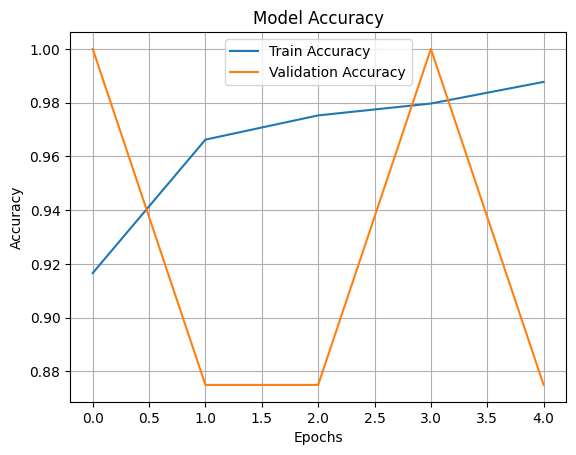

In [16]:
# Visualize Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### Conclusion

This lab introduced the use of Convolutional Neural Networks (CNNs) for diagnosing diseases like pneumonia from X-ray images. We built and trained a deep learning model that automatically extracted features from medical images, showcasing the power of AI in medical imaging.

### Postlab

### **1. Key Differences Between MRI and X-ray Images for AI Models**

| **Feature**          | **MRI**                            | **X-ray**                     |
| -------------------- | ---------------------------------- | ----------------------------- |
| **Data Type**        | High-resolution soft tissue images | Low-cost, bone/density images |
| **Use Case**         | Brain, spine, joints, tumors       | Chest, fractures, lungs       |
| **Complexity**       | 3D or multi-slice, grayscale       | 2D grayscale                  |
| **AI Preprocessing** | Intensity normalization, resizing  | Resizing, denoising           |

---

### **2. Why Are CNNs Preferred for Medical Image Diagnosis?**

* Automatically extract features (no manual feature engineering required)
* Detect subtle textures and shapes (e.g., tumors, nodules)
* Learn in a hierarchical manner: edges → patterns → objects
* Suitable for classification, detection, and segmentation tasks
* Generalize well across different types of medical images

---

### **3. Main Steps to Build an AI Model for MRI/X-ray Diagnosis**

1. **Data Collection**

   * Gather labeled MRI or X-ray images (e.g., from hospitals or open datasets)

2. **Preprocessing**

   * Resize and normalize images
   * Data augmentation (flipping, rotation, contrast)
   * Handle class imbalance (oversampling, class weights)

3. **Model Building**

   * Use CNN-based architectures (e.g., ResNet, VGG, U-Net for segmentation)

4. **Training**

   * Train the model using labeled data and backpropagation

5. **Validation & Testing**

   * Evaluate performance using metrics like accuracy, precision, recall, F1-score, AUC

6. **Deployment**

   * Integrate the trained model into clinical systems or apps for real-world usage